# Análisis Estructural de Vigas Contínuas
## Método de Rigidez (Método de los Elementos Finitos)

---

> **Autor:** Mario Cesgo S.  
> **Tema:** Análisis Estructural Matricial  
> **Método:** Rigidez Directa / Elementos Finitos (FEM)

---

## 1. Fundamentos Teóricos

### 1.1 ¿Qué es el Método de Rigidez?

El **Método de Rigidez** (o Método de Desplazamientos) es un procedimiento sistemático para analizar estructuras que:

- Toma como **incógnitas primarias** los **desplazamientos y giros** en los nudos.
- Construye un sistema de ecuaciones lineales de la forma:

$$\boxed{[K]\{U\} = \{F\}}$$

donde:
- $[K]$ = Matriz de rigidez global de la estructura
- $\{U\}$ = Vector de desplazamientos y giros nodales (incógnitas)
- $\{F\}$ = Vector de fuerzas y momentos nodales equivalentes

---

### 1.2 Elemento Viga de Euler-Bernoulli

Cada tramo de la viga continua se modela como un **elemento viga de Euler-Bernoulli** con **4 grados de libertad (GDL)**:

```
  v₁, θ₁                    v₂, θ₂
   ↕  ↺                      ↕  ↺
   ●━━━━━━━━━━━━━━━━━━━━━━━━━●
  (1)          L            (2)
```

| GDL | Símbolo | Descripción |
|-----|---------|-------------|
| 1 | $v_1$ | Desplazamiento vertical nudo izquierdo |
| 2 | $\theta_1$ | Giro nudo izquierdo |
| 3 | $v_2$ | Desplazamiento vertical nudo derecho |
| 4 | $\theta_2$ | Giro nudo derecho |

---

### 1.3 Matriz de Rigidez Local del Elemento

Para un elemento viga con longitud $L$, módulo de elasticidad $E$ y momento de inercia $I$:

$$[k_e] = \frac{EI}{L^3}
\begin{bmatrix}
12 & 6L & -12 & 6L \\
6L & 4L^2 & -6L & 2L^2 \\
-12 & -6L & 12 & -6L \\
6L & 2L^2 & -6L & 4L^2
\end{bmatrix}$$

Esta matriz es **simétrica** y relaciona fuerzas ↔ desplazamientos en los extremos del elemento.

---

### 1.4 Cargas de Empotramiento Equivalentes (CEE)

Para una **carga distribuida uniforme** $w$ (N/m) actuando sobre el elemento, las cargas equivalentes en los nudos — asumiendo que los extremos están empotrados — son:

$$\{f_{emp}\} =
\begin{Bmatrix}
-wL/2 \\
-wL^2/12 \\
-wL/2 \\
+wL^2/12
\end{Bmatrix}$$

Estas cargas se ensamblan en el vector de cargas global para representar el efecto de la carga distribuida sobre la estructura.

> ⚠️ **Nota:** El signo negativo en la fuerza cortante indica que la carga actúa hacia **abajo** (sentido positivo hacia arriba en la convención utilizada).

---

### 1.5 Funciones de Forma (Shape Functions)

Para calcular la deflexión en cualquier punto $x$ del elemento, se usan las **funciones de forma de Hermite**:

$$v(x) = N_1(x)\,v_1 + N_2(x)\,\theta_1 + N_3(x)\,v_2 + N_4(x)\,\theta_2$$

donde $\xi = x/L$:

$$N_1 = 1 - 3\xi^2 + 2\xi^3, \quad N_2 = x(1 - \xi)^2$$
$$N_3 = 3\xi^2 - 2\xi^3, \quad N_4 = x(\xi^2 - \xi)$$

## 2. Procedimiento General del Análisis

El análisis sigue estos pasos sistemáticos:

#### PASO 1: Discretización
- Dividir la viga en *n* tramos (elementos).
- Identificar *n+1* nudos y sus GDL.

#### PASO 2: Matrices Locales
- Calcular [k_e] y {f_emp} para cada elemento.

#### PASO 3: Ensamblaje Global
- Construir [K] y {F} sumando contribuciones.

#### PASO 4: Condiciones de Frontera
- Aplicar restricciones (apoyos) al sistema.

#### PASO 5: Resolver el Sistema Reducido
- [K_red]{U_libre} = {F_red} → {U}.

#### PASO 6: Post-procesamiento
- Calcular reacciones, V(x), M(x), y(x).
---

### 2.1 Numeración de GDL

Para una viga con $n$ tramos y $n+1$ nudos, el total de GDL es $2(n+1)$.

La numeración es:
- Nudo $i$ → GDL $2i$ (desplazamiento vertical) y GDL $2i+1$ (giro)

Ejemplo para 3 tramos (4 nudos, 8 GDL):

```
GDL:  0,1      2,3      4,5      6,7
       ●────────●────────●────────●
      [0]      [1]      [2]      [3]   ← nudos
      Tramo 1       Tramo 2       Tramo 3
```

## 3. Tipos de Apoyos y Condiciones de Frontera

### Tipos de Apoyo Implementados

| Tipo | Símbolo | Restricciones | GDL Bloqueados |
|------|---------|---------------|----------------|
| **Móvil** (simple) | △ | Desplazamiento vertical | $v_i = 0$ |
| **Fijo** (empotrado) | ▲ | Desplazamiento + giro | $v_i = 0,\ \theta_i = 0$ |

> ⚠️ **Importante:** En este modelo, **todos los apoyos restringen el desplazamiento vertical**. La diferencia entre apoyo fijo y móvil es si también se restringe el **giro** $\theta$.


### Restricción: Estabilidad del Sistema

Para que el sistema sea **estáticamente estable** y la matriz reducida $[K_{red}]$ sea invertible:

- Se deben restringir al menos **todos los desplazamientos verticales** (un apoyo por nudo).
- Al menos un nudo debe restringir también el **giro** (o el sistema es mecanismo).
- Para vigas continuas simétricas con apoyos simples en todos los nudos, el sistema es estable porque los giros libres crean un sistema de ecuaciones determinado.

## 4. Fórmulas para el Post-procesamiento

Una vez obtenidos los desplazamientos nodales $\{U\}$, se calculan las fuerzas internas:

### 4.1 Fuerzas Internas en el Elemento

$$\{f_{int}\} = [k_e]\{u_e\} + \{f_{emp}\}$$

donde $\{u_e\}$ son los desplazamientos del elemento extraídos de $\{U\}$.

Los valores en el extremo izquierdo del tramo:
- Cortante: $V_0 = f_{int,1}$
- Momento:  $M_0 = -f_{int,2}$

### 4.2 Cortante en el Tramo (carga distribuida uniforme $w$)

$$V(x) = V_0 - w \cdot x$$

### 4.3 Momento Flector en el Tramo

$$M(x) = M_0 + V_0 \cdot x - \frac{w \cdot x^2}{2}$$

### 4.4 Deflexión en el Tramo

$$y(x) = \{N(x)\}^T \{u_e\} - \frac{w x^2 (L-x)^2}{24EI}$$

donde $\{N(x)\}$ son las funciones de forma de Hermite evaluadas en $x$.

### 4.5 Reacciones en los Apoyos

$$\{R\} = [K]\{U\} - \{F\}$$

Las reacciones verticales en el nudo $i$ corresponden al GDL $2i$.

> 📌 **Nota de signo:** El momento $M$ se grafica con el **eje invertido** (convención de vigas: momentos positivos hacia abajo en la fibra inferior tensionada).

## 5. Restricciones y Supuestos del Modelo

| # | Supuesto / Restricción | Descripción |
|---|------------------------|-------------|
| 1 | **Teoría de Euler-Bernoulli** | Las secciones planas permanecen planas; se desprecian deformaciones por cortante. Válido para vigas esbeltas ($L/h > 10$). |
| 2 | **Material lineal elástico** | La relación tensión-deformación es lineal. $E$ e $I$ son constantes en toda la viga. |
| 3 | **Pequeñas deformaciones** | Los desplazamientos son pequeños comparados con las dimensiones de la viga. |
| 4 | **Carga distribuida uniforme** | Solo se admiten cargas $w$ (N/m) uniformes por tramo. No se modelan cargas concentradas ni momentos aplicados directamente. |
| 5 | **Sección transversal constante** | $E$ e $I$ son los mismos para todos los tramos. |
| 6 | **Desplazamiento axial nulo** | No se considera deformación longitudinal (viga horizontal). |
| 7 | **Apoyos rígidos** | Los apoyos no tienen deformación ni asentamiento. |

> ⚠️ **Limitaciones actuales del código:**
> - No admite cargas concentradas intermedias (solo $w$ uniforme por tramo).
> - No modela apoyos con resorte (spring supports).
> - No calcula efectos de segundo orden (análisis P-Δ).

## 6. Implementación en Python

### 6.1 Importación de Librerías

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### 6.2 Función Principal de Análisis

La función `analizar_viga_final` realiza los **pasos 1 al 5** del procedimiento:

**Parámetros de entrada:**
- `longitudes` → Lista de longitudes de cada tramo (m)
- `cargas_w` → Lista de cargas distribuidas por tramo (N/m)
- `E` → Módulo de elasticidad (Pa)
- `I` → Momento de inercia de la sección (m⁴)
- `tipos_apoyo` → Lista de strings con el tipo de apoyo en cada nudo (`'movil'` o `'fijo'`)

**Retorna un diccionario** con todos los resultados para graficar y analizar.

In [4]:
def analizar_viga_final(longitudes, cargas_w, E, I, tipos_apoyo=None):
    if len(longitudes) != len(cargas_w):
        print("⚠️ Las listas de tramos y cargas deben tener el mismo tamaño.")
        return None

    # Valor por defecto: todos los apoyos son móviles
    if tipos_apoyo is None:
        tipos_apoyo = ['movil'] * (len(longitudes) + 1)

    n_tramos = len(longitudes)
    n_nudos  = n_tramos + 1
    n_gdl    = n_nudos * 2          # 2 GDL por nudo: v (par) y θ (impar)

    # ── Inicializar matrices globales ─────────────────────────────────────────
    K_global = np.zeros((n_gdl, n_gdl))
    F_global = np.zeros(n_gdl)

    # ─────────────────────────────────────────────────────────────────────────
    # PASO 1-3: Ensamblaje de la Matriz de Rigidez Global y Vector de Cargas
    # ─────────────────────────────────────────────────────────────────────────
    for i in range(n_tramos):
        L, w = longitudes[i], cargas_w[i]

        # Matriz de rigidez local [k_e] = (EI/L³) × [...]
        k_local = (E * I / L**3) * np.array([
            [ 12,   6*L,  -12,   6*L],
            [6*L,  4*L**2, -6*L, 2*L**2],
            [-12,  -6*L,   12,  -6*L],
            [6*L,  2*L**2, -6*L, 4*L**2]
        ])

        # Cargas de empotramiento equivalentes para carga uniforme w
        v_emp = w * L / 2          # Reacción cortante de empotramiento
        m_emp = w * L**2 / 12      # Momento de empotramiento
        f_local_emp = np.array([-v_emp, -m_emp, -v_emp, m_emp])

        # Índices globales del elemento i: nudos i e i+1
        idx = [2*i, 2*i+1, 2*i+2, 2*i+3]

        # Ensamblaje por sumatoria directa
        for r in range(4):
            for c in range(4):
                K_global[idx[r], idx[c]] += k_local[r, c]
            F_global[idx[r]] += f_local_emp[r]

    # ─────────────────────────────────────────────────────────────────────────
    # PASO 4: Condiciones de Frontera (Apoyos)
    # ─────────────────────────────────────────────────────────────────────────
    gdl_restringidos = []
    info_apoyos = []

    for i in range(n_nudos):
        tipo = tipos_apoyo[i] if i < len(tipos_apoyo) else 'movil'

        gdl_vertical = 2 * i          # GDL par → desplazamiento vertical
        gdl_restringidos.append(gdl_vertical)

        # Apoyo fijo: también restringe el giro (GDL impar)
        if tipo == 'fijo':
            gdl_giro = 2 * i + 1
            gdl_restringidos.append(gdl_giro)

        info_apoyos.append({'nudo': i, 'tipo': tipo,
                            'gdl_restringidos': [gdl_vertical]})

    gdl_restringidos = list(set(gdl_restringidos))   # Eliminar duplicados
    gdl_libres = [i for i in range(n_gdl) if i not in gdl_restringidos]

    # ─────────────────────────────────────────────────────────────────────────
    # PASO 5: Resolver el Sistema Reducido  [K_red]{U_libre} = {F_red}
    # ─────────────────────────────────────────────────────────────────────────
    K_red = K_global[np.ix_(gdl_libres, gdl_libres)]
    F_red = F_global[gdl_libres]
    giros = np.linalg.solve(K_red, F_red)  # Resolución del sistema lineal

    # Vector de desplazamientos completo
    U = np.zeros(n_gdl)
    U[gdl_libres] = giros

    # Reacciones: R = [K]{U} - {F}
    reacciones = np.dot(K_global, U) - F_global

    # ─────────────────────────────────────────────────────────────────────────
    # PASO 6: Post-procesamiento — V(x), M(x), y(x) para cada tramo
    # ─────────────────────────────────────────────────────────────────────────
    x_total, V_total, M_total, Def_total = [], [], [], []
    tramos_data = []
    x_acumulado = 0

    for i in range(n_tramos):
        L, w = longitudes[i], cargas_w[i]
        u_elem = U[2*i: 2*i+4]   # GDL del elemento: [v1, θ1, v2, θ2]

        # Rigidez local y fuerzas de empotramiento del tramo
        k_local_i = (E * I / L**3) * np.array([
            [ 12,   6*L,  -12,   6*L],
            [6*L,  4*L**2, -6*L, 2*L**2],
            [-12,  -6*L,   12,  -6*L],
            [6*L,  2*L**2, -6*L, 4*L**2]
        ])
        f_emp_local = np.array([w*L/2, w*L**2/12, w*L/2, -w*L**2/12])

        # Fuerzas internas: {f_int} = [k_e]{u_e} + {f_emp}
        f_internas = np.dot(k_local_i, u_elem) + f_emp_local

        V_izq =  f_internas[0]   # Cortante en extremo izquierdo
        M_izq = -f_internas[1]   # Momento en extremo izquierdo

        puntos_x = np.linspace(0, L, 200)
        x_tramo, V_tramo, M_tramo, Def_tramo = [], [], [], []

        for px in puntos_x:
            # V(x) = V₀ - w·x
            Vx = V_izq - w * px
            # M(x) = M₀ + V₀·x - w·x²/2
            Mx = M_izq + V_izq * px - 0.5 * w * px**2

            # Funciones de forma de Hermite en x
            xi = px / L
            N = np.array([
                1 - 3*xi**2 + 2*xi**3,
                px * (1 - xi)**2,
                3*xi**2 - 2*xi**3,
                px * (xi**2 - xi)
            ])
            # y(x) = N·u_e - corrección por carga distribuida
            y_def = np.dot(N, u_elem) - (w * px**2 * (L - px)**2) / (24 * E * I)

            x_tramo.append(px + x_acumulado)
            V_tramo.append(Vx)
            M_tramo.append(Mx)
            Def_tramo.append(y_def)

        x_total.extend(x_tramo)
        V_total.extend(V_tramo)
        M_total.extend(M_tramo)
        Def_total.extend(Def_tramo)

        tramos_data.append({
            'x': x_tramo, 'V': V_tramo, 'M': M_tramo, 'Def': Def_tramo,
            'x_ini': x_acumulado, 'x_fin': x_acumulado + L,
            'x_mid': x_acumulado + L / 2, 'L': L, 'w': w,
        })
        x_acumulado += L

    posiciones_apoyos = [0] + list(np.cumsum(longitudes))
    L_total = posiciones_apoyos[-1]

    return {
        'posiciones_apoyos': posiciones_apoyos,
        'L_total': L_total,
        'reacciones': reacciones,
        'tramos_data': tramos_data,
        'x_total': x_total,
        'V_total': V_total,
        'M_total': M_total,
        'Def_total': Def_total,
        'info_apoyos': info_apoyos,
        'tipos_apoyo': tipos_apoyo
    }

### 6.3 Función de Visualización

La función `plot_beam_results` genera una figura con **5 subplots**:

1. **Esquema de la viga** — geometría, cargas y tipos de apoyo
2. **Reacciones en apoyos** — fuerzas verticales en cada soporte
3. **Diagrama de Fuerza Cortante V(x)**
4. **Diagrama de Momento Flector M(x)**
5. **Diagrama de Deflexión y(x)**

In [5]:
def plot_beam_results(posiciones_apoyos, L_total, reacciones, tramos_data,
                      x_total, V_total, M_total, Def_total, info_apoyos=None):
    """
    Genera la figura completa con esquema, reacciones y diagramas estructurales.

    Subplots:
        1. Esquema de la viga (cargas, longitudes, apoyos)
        2. Reacciones en apoyos (kN)
        3. Diagrama de Fuerza Cortante V(x) [kN]
        4. Diagrama de Momento Flector M(x) [kN·m]
        5. Diagrama de Deflexión y(x) [mm]
    """
    # ── Helper: anotar un punto con flecha ────────────────────────────────────
    def anotar(ax, x, y, label, color, offset_y=12, offset_x=0, fontsize=7.5):
        ax.annotate(
            label, xy=(x, y), xytext=(offset_x, offset_y),
            textcoords='offset points', ha='center', va='bottom',
            fontsize=fontsize, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=0.8),
        )

    # ── Helper: ubicar cruces de V con el eje cero ────────────────────────────
    def x_V_cero(td):
        """Interpolación lineal para encontrar x donde V(x) = 0 (máximo de M)."""
        V = np.array(td['V'])
        x = np.array(td['x'])
        crosses = np.where(np.diff(np.sign(V)))[0]
        results = []
        for c in crosses:
            x0, x1, v0, v1 = x[c], x[c+1], V[c], V[c+1]
            xz = x0 - v0 * (x1 - x0) / (v1 - v0)
            idx = np.argmin(np.abs(x - xz))
            results.append((xz, td['M'][idx]))
        return results

    # ── Configuración de la figura ────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 21))
    gs = fig.add_gridspec(5, 1, height_ratios=[2.4, 1.1, 1.4, 1.4, 1.4],
                          hspace=0.60)
    ax_viga = fig.add_subplot(gs[0])
    ax_reac = fig.add_subplot(gs[1])
    ax_V    = fig.add_subplot(gs[2], sharex=ax_reac)
    ax_M    = fig.add_subplot(gs[3], sharex=ax_reac)
    ax_Def  = fig.add_subplot(gs[4], sharex=ax_reac)

    fig.suptitle("ANÁLISIS ESTRUCTURAL DE VIGAS CONTÍNUAS   |  Autor: Mario Cesgo S.",
                 fontsize=14, fontweight='bold', y=0.998)

    # ─────────────────────────────────────────────────────────────────────────
    # SUBPLOT 1 — ESQUEMA DE LA VIGA
    # ─────────────────────────────────────────────────────────────────────────
    ax_viga.set_xlim(-0.4, L_total + 0.4)
    ax_viga.set_ylim(-0.28, 0.62)
    ax_viga.axis('off')
    ax_viga.set_title("Esquema de la Viga", fontsize=10, fontweight='bold', pad=4)

    # Línea de la viga
    ax_viga.plot([0, L_total], [0, 0], color='saddlebrown', lw=6, zorder=3,
                 solid_capstyle='butt')

    # Dibujar apoyos con su símbolo correspondiente
    for i, loc in enumerate(posiciones_apoyos):
        tipo = info_apoyos[i]['tipo'] if info_apoyos and i < len(info_apoyos) else 'movil'

        if tipo == 'fijo':
            ax_viga.plot(loc, -0.028, '^', color='darkred', markersize=15, zorder=4,
                         markeredgecolor='black', markeredgewidth=0.8)
            ax_viga.plot([loc - 0.18, loc + 0.18], [-0.06, -0.06],
                         color='darkred', lw=2.5)
            ax_viga.text(loc, -0.1, 'Fijo', ha='center', va='top',
                         fontsize=8, color='darkred', fontweight='bold')
        else:
            ax_viga.plot(loc, -0.028, '^', color='dimgray', markersize=15, zorder=4,
                         markeredgecolor='black', markeredgewidth=0.8)
            ax_viga.plot([loc - 0.18, loc + 0.18], [-0.07, -0.07],
                         color='dimgray', lw=2.5)
            ax_viga.text(loc, -0.1, 'Móvil', ha='center', va='top',
                         fontsize=8, color='dimgray', fontweight='bold')

    # Cargas distribuidas y cotas de longitud
    arrow_top = 0.2
    arrow_bot = 0.05
    n_flechas = 7

    for td in tramos_data:
        x_ini, x_fin = td['x_ini'], td['x_fin']
        w_kNm = td['w'] / 1000

        ax_viga.plot([x_ini, x_fin], [arrow_top, arrow_top],
                     color='steelblue', lw=2.2)

        for xf in np.linspace(x_ini, x_fin, n_flechas):
            ax_viga.annotate(
                '', xy=(xf, arrow_bot), xytext=(xf, arrow_top),
                arrowprops=dict(arrowstyle='->', color='steelblue',
                                lw=1.4, mutation_scale=11)
            )

        ax_viga.text(td['x_mid'], arrow_top + 0.045,
                     f'w = {w_kNm:.1f} kN/m',
                     ha='center', va='bottom', fontsize=9.5,
                     color='steelblue', fontweight='bold')

        y_cota = -0.15
        y_tick = -0.13
        for xc in [x_ini, x_fin]:
            ax_viga.plot([xc, xc], [y_tick, y_cota], color='black', lw=1.2)
        ax_viga.annotate(
            '', xy=(x_fin, y_cota), xytext=(x_ini, y_cota),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.3, mutation_scale=11)
        )
        ax_viga.text(td['x_mid'], y_cota - 0.045,
                     f'L = {td["L"]:.1f} m',
                     ha='center', va='top', fontsize=9.5,
                     color='black', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────────────
    # SUBPLOT 2 — REACCIONES EN APOYOS
    # ─────────────────────────────────────────────────────────────────────────
    ax_reac.axhline(0, color='black', lw=2.5)
    for i, loc in enumerate(posiciones_apoyos):
        ax_reac.plot(loc, 0, '^r', markersize=12, zorder=4)
        R_kN = reacciones[2*i] / 1000
        ax_reac.annotate(
            f'R = {R_kN:.2f} kN',
            (loc, 0), xytext=(0, 17),
            textcoords='offset points', ha='center',
            fontsize=9, fontweight='bold', color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8)
        )
    ax_reac.set_title("Reacciones en Apoyos", fontsize=10, fontweight='bold')
    ax_reac.set_yticks([])
    ax_reac.set_ylim(-0.04, 0.065)
    for xv in posiciones_apoyos:
        ax_reac.axvline(xv, color='gray', lw=0.5, ls=':')

    # ─────────────────────────────────────────────────────────────────────────
    # SUBPLOT 3 — DIAGRAMA DE CORTANTE V(x)
    # ─────────────────────────────────────────────────────────────────────────
    ax_V.axhline(0, color='black', lw=0.8, ls='--')
    ax_V.fill_between(x_total, V_total, color='green', alpha=0.25)
    ax_V.plot(x_total, V_total, 'g', lw=1.5)

    for td in tramos_data:
        V_arr = np.array(td['V'])
        x_arr = np.array(td['x'])
        V_ini, V_fin = V_arr[0], V_arr[-1]

        ax_V.plot(td['x_ini'], V_ini, 'go', ms=4)
        ax_V.plot(td['x_fin'], V_fin, 'go', ms=4)
        anotar(ax_V, td['x_ini'], V_ini, f'{V_ini/1000:.2f} kN', 'darkgreen',
               offset_y=10 if V_ini >= 0 else -14)
        anotar(ax_V, td['x_fin'], V_fin, f'{V_fin/1000:.2f} kN', 'darkgreen',
               offset_y=10 if V_fin >= 0 else -14)

        idx_max = np.argmax(np.abs(V_arr))
        if 0.05 * len(V_arr) < idx_max < 0.95 * len(V_arr):
            V_ext = V_arr[idx_max]
            ax_V.plot(x_arr[idx_max], V_ext, 'g^', ms=5)
            anotar(ax_V, x_arr[idx_max], V_ext, f'{V_ext/1000:.2f} kN', 'green',
                   offset_y=10 if V_ext >= 0 else -14)

        for xv in [td['x_ini'], td['x_fin']]:
            ax_V.axvline(xv, color='gray', lw=0.5, ls=':')

    ax_V.set_title("Diagrama de Fuerza Cortante (V)", fontsize=10, fontweight='bold')
    ax_V.set_ylabel("V (kN)")
    ax_V.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}'))
    ax_V.grid(True, alpha=0.4)

    # ─────────────────────────────────────────────────────────────────────────
    # SUBPLOT 4 — DIAGRAMA DE MOMENTO FLECTOR M(x)
    # ─────────────────────────────────────────────────────────────────────────
    ax_M.axhline(0, color='black', lw=0.8, ls='--')
    ax_M.fill_between(x_total, M_total, color='red', alpha=0.25)
    ax_M.plot(x_total, M_total, 'r', lw=1.5)

    for td in tramos_data:
        M_arr = np.array(td['M'])
        x_arr = np.array(td['x'])
        M_ini, M_fin = M_arr[0], M_arr[-1]

        ax_M.plot(td['x_ini'], M_ini, 'ro', ms=4)
        ax_M.plot(td['x_fin'], M_fin, 'ro', ms=4)
        anotar(ax_M, td['x_ini'], M_ini, f'{M_ini/1000:.2f} kN·m', 'darkred',
               offset_y=-14 if M_ini >= 0 else 10)
        anotar(ax_M, td['x_fin'], M_fin, f'{M_fin/1000:.2f} kN·m', 'darkred',
               offset_y=-14 if M_fin >= 0 else 10)

        # Anotar momentos donde V = 0 (máximos/mínimos de M)
        for xz, Mz in x_V_cero(td):
            ax_M.plot(xz, Mz, 'r^', ms=6)
            anotar(ax_M, xz, Mz, f'{Mz/1000:.2f} kN·m', 'red',
                   offset_y=-14 if Mz >= 0 else 10)

        for xv in [td['x_ini'], td['x_fin']]:
            ax_M.axvline(xv, color='gray', lw=0.5, ls=':')

    ax_M.set_title("Diagrama de Momento Flector (M)", fontsize=10, fontweight='bold')
    ax_M.set_ylabel("M (kN·m)")
    ax_M.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}'))
    ax_M.invert_yaxis()   # Convención: momentos positivos hacia abajo
    ax_M.grid(True, alpha=0.4)

    # ─────────────────────────────────────────────────────────────────────────
    # SUBPLOT 5 — DIAGRAMA DE DEFLEXIÓN y(x)
    # ─────────────────────────────────────────────────────────────────────────
    Def_mm = np.array(Def_total) * 1000   # Convertir de m a mm
    ax_Def.axhline(0, color='black', lw=0.8, ls='--')
    ax_Def.plot(x_total, Def_mm, 'b', lw=1.5)
    ax_Def.fill_between(x_total, Def_mm, color='blue', alpha=0.15)

    for td in tramos_data:
        Def_arr = np.array(td['Def']) * 1000
        x_arr   = np.array(td['x'])
        idx_min = np.argmin(Def_arr)    # Deflexión máxima (hacia abajo = negativa)
        D_min   = Def_arr[idx_min]
        ax_Def.plot(x_arr[idx_min], D_min, 'bv', ms=6)
        anotar(ax_Def, x_arr[idx_min], D_min,
               f'{D_min:.3f} mm', 'blue', offset_y=-16)

        for xv in [td['x_ini'], td['x_fin']]:
            ax_Def.axvline(xv, color='gray', lw=0.5, ls=':')

    ax_Def.set_title("Diagrama de Deflexión", fontsize=10, fontweight='bold')
    ax_Def.set_ylabel("Deflexión (mm)")
    ax_Def.set_xlabel("Longitud (m)")
    ax_Def.grid(True, alpha=0.4)

    plt.savefig("viga_anotada.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Gráfico guardado como 'viga_anotada.png'")

## 7. Datos de Entrada del Problema

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DATOS DE ENTRADA — modificar según el problema a resolver
# ─────────────────────────────────────────────────────────────────────────────
#Se analiza una viga contínua de 5 tramos con las siguientes características:

L_tramos   = [2, 3.4, 5.89, 4.345, 6.5]   # Longitudes de tramo (m)
W_tramos   = [12, 15, 12, 20, 15]          # Cargas distribuidas (kN/m)
E_material = 200e9                          # Módulo de elasticidad (Pa) → 200 GPa
I_seccion  = 0.0005                         # Inercia de sección (m⁴)

# Tipos de apoyo para cada nudo (len(L_tramos) + 1 = 6 nudos)
# Opciones: 'movil' → restringe v,   'fijo' → restringe v y θ
tipos_apoyo_nudos = ['fijo', 'movil', 'movil', 'movil', 'movil', 'movil']

print(f"Número de tramos: {len(L_tramos)}")
print(f"Número de nudos:  {len(L_tramos) + 1}")
print(f"Longitud total:   {sum(L_tramos):.3f} m")
print(f"EI = {E_material * I_seccion / 1e3:.0f} kN·m²")

Número de tramos: 5
Número de nudos:  6
Longitud total:   22.135 m
EI = 100000 kN·m²


## 8. Ejecución del Análisis

In [7]:
# Ejecutar el análisis (cargas convertidas de kN/m a N/m)
results = analizar_viga_final(
    L_tramos,
    [w * 1000 for w in W_tramos],   # kN/m → N/m
    E_material,
    I_seccion,
    tipos_apoyo=tipos_apoyo_nudos
)

if results is not None:
    print("✅ Análisis completado correctamente.")
else:
    print("❌ Error en los datos de entrada.")

✅ Análisis completado correctamente.


## 9. Resultados Numéricos

In [9]:
if results is not None:
    posiciones_apoyos = results['posiciones_apoyos']
    L_total           = results['L_total']
    reacciones        = results['reacciones']
    tramos_data       = results['tramos_data']
    x_total           = results['x_total']
    V_total           = results['V_total']
    M_total           = results['M_total']
    Def_total         = results['Def_total']
    info_apoyos       = results['info_apoyos']

    # ── Configuración de apoyos ───────────────────────────────────────────────
    print("=" * 55)
    print("          RESUMEN DE RESULTADOS")
    print("=" * 55)

    print("\n📌 Configuración de apoyos:")
    for i, info in enumerate(info_apoyos):
        print(f"   Nudo {i} (x = {posiciones_apoyos[i]:.3f} m): "
              f"Apoyo {info['tipo'].upper()}")

    # ── Reacciones ────────────────────────────────────────────────────────────
    print("\n⬆️  Reacciones verticales en los apoyos:")
    suma_R = 0
    for i, loc in enumerate(posiciones_apoyos):
        if 2*i < len(reacciones):
            R_kN = reacciones[2*i] / 1000
            suma_R += R_kN
            print(f"   Apoyo {i+1} (x = {loc:.3f} m): R = {R_kN:.4f} kN")
    print(f"   ─────────────────────────────────")
    print(f"   ΣR = {suma_R:.4f} kN")

    # Verificación de equilibrio
    carga_total = sum(w * L for w, L in zip(W_tramos, L_tramos))
    print(f"   Carga total aplicada = {carga_total:.4f} kN")
    print(f"   Error de equilibrio  = {abs(suma_R - carga_total):.6f} kN")

    # ── Cortante y Momento por tramo ─────────────────────────────────────────
    print("\n📊 Fuerza Cortante y Momento Flector por tramo:")
    for i, td in enumerate(tramos_data):
        V_arr = np.array(td['V'])
        x_arr = np.array(td['x'])
        M_arr = np.array(td['M'])

        print(f"\n   ── Tramo {i+1}  (L = {td['L']:.3f} m, "
              f"w = {td['w']/1000:.1f} kN/m) ──")
        print(f"      V(x_ini) = {V_arr[0]/1000:.4f} kN")
        print(f"      V(x_fin) = {V_arr[-1]/1000:.4f} kN")
        print(f"      M(x_ini) = {M_arr[0]/1000:.4f} kN·m")
        print(f"      M(x_fin) = {M_arr[-1]/1000:.4f} kN·m")

        # Punto de momento máximo (donde V = 0)
        crosses = np.where(np.diff(np.sign(V_arr)))[0]
        for c in crosses:
            x0, x1 = x_arr[c], x_arr[c+1]
            v0, v1 = V_arr[c], V_arr[c+1]
            xz = x0 - v0 * (x1 - x0) / (v1 - v0)
            idx_z = np.argmin(np.abs(x_arr - xz))
            Mmax = M_arr[idx_z]
            print(f"      M_máx   = {Mmax/1000:.4f} kN·m  @ x = {xz:.4f} m (donde V = 0)")

          RESUMEN DE RESULTADOS

📌 Configuración de apoyos:
   Nudo 0 (x = 0.000 m): Apoyo FIJO
   Nudo 1 (x = 2.000 m): Apoyo MOVIL
   Nudo 2 (x = 5.400 m): Apoyo MOVIL
   Nudo 3 (x = 11.290 m): Apoyo MOVIL
   Nudo 4 (x = 15.635 m): Apoyo MOVIL
   Nudo 5 (x = 22.135 m): Apoyo MOVIL

⬆️  Reacciones verticales en los apoyos:
   Apoyo 1 (x = 0.000 m): R = 10.8643 kN
   Apoyo 2 (x = 2.000 m): R = 31.1442 kN
   Apoyo 3 (x = 5.400 m): R = 68.8089 kN
   Apoyo 4 (x = 11.290 m): R = 70.8161 kN
   Apoyo 5 (x = 15.635 m): R = 109.0420 kN
   Apoyo 6 (x = 22.135 m): R = 39.4045 kN
   ─────────────────────────────────
   ΣR = 330.0800 kN
   Carga total aplicada = 330.0800 kN
   Error de equilibrio  = 0.000000 kN

📊 Fuerza Cortante y Momento Flector por tramo:

   ── Tramo 1  (L = 2.000 m, w = 12.0 kN/m) ──
      V(x_ini) = 10.8643 kN
      V(x_fin) = -13.1357 kN
      M(x_ini) = -3.2429 kN·m
      M(x_fin) = -5.5142 kN·m
      M_máx   = 1.6752 kN·m  @ x = 0.9054 m (donde V = 0)

   ── Tramo 2  (L =

## 10. Diagramas Estructurales

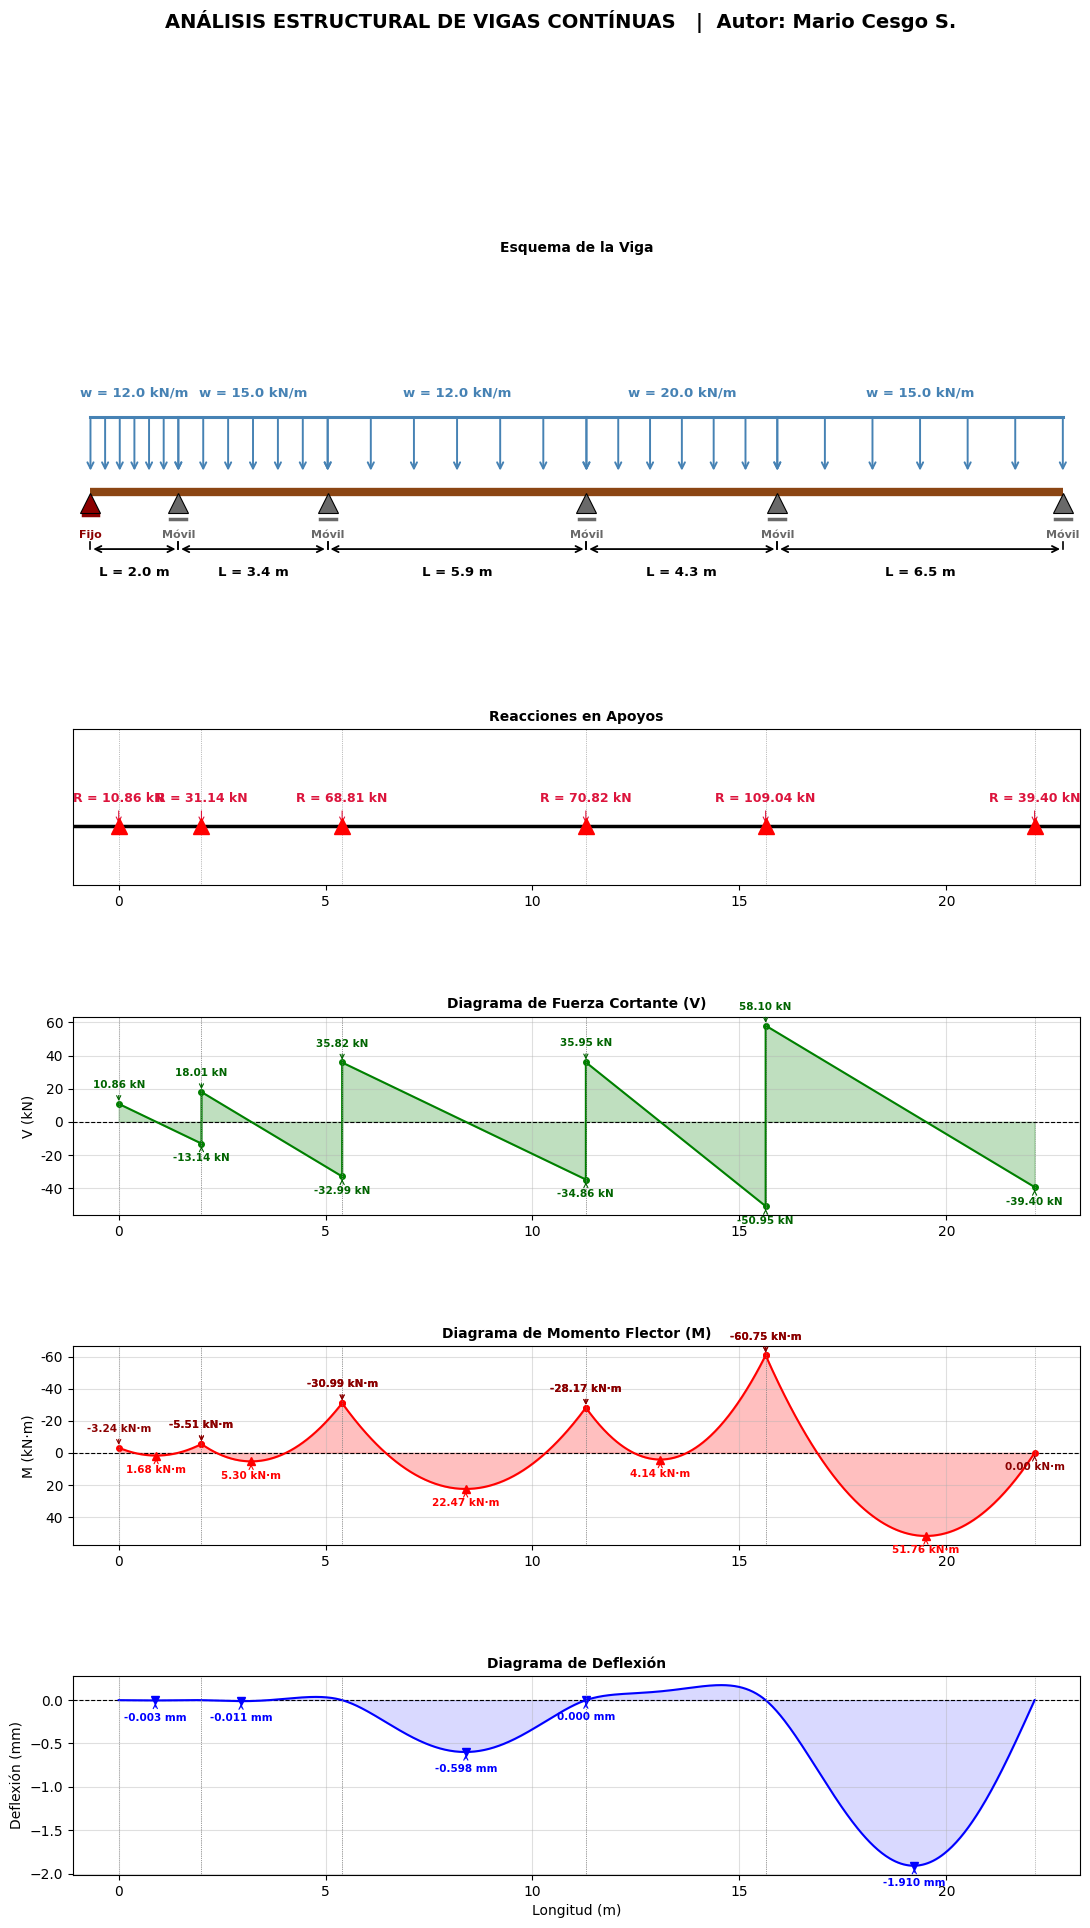

✅ Gráfico guardado como 'viga_anotada.png'


In [10]:
if results is not None:
    plot_beam_results(
        posiciones_apoyos, L_total, reacciones, tramos_data,
        x_total, V_total, M_total, Def_total, info_apoyos
    )

## 11. Verificación de Resultados

### Verificación de Equilibrio Global

Para validar que los resultados son correctos, se comprueba el **equilibrio de fuerzas verticales**:

$$\sum R_i = \sum w_j \cdot L_j$$

Es decir, la suma de todas las reacciones debe ser igual a la carga total aplicada.

### Verificación en Apoyos

- En los apoyos **móviles**: el desplazamiento vertical debe ser $v = 0$.
- En el apoyo **fijo**: además, $\theta = 0$.
- En los extremos libres (si los hubiera): el momento debe ser $M = 0$.

### Propiedades del Diagrama de Momentos

- El momento es **máximo o mínimo** donde la fuerza cortante cambia de signo ($V = 0$).
- En los apoyos simples (extremos de la viga continua no empotrados): $M = 0$.
- La pendiente del diagrama de momentos es igual a la fuerza cortante: $\dfrac{dM}{dx} = V(x)$.

## 12. Guía para Modificar el Análisis

Para analizar una viga diferente, solo se deben modificar los **Datos de Entrada** de la Sección 7:

```python
# ─── Ejemplo: viga de 3 tramos ────────────────────────────────────────────
L_tramos   = [4.0, 6.0, 5.0]         # 3 tramos
W_tramos   = [20, 15, 25]             # kN/m por tramo
E_material = 200e9                    # Acero: 200 GPa
I_seccion  = 8.356e-5                 # Perfil IPE300: I = 8.356×10⁻⁵ m⁴

# 4 nudos para 3 tramos
tipos_apoyo_nudos = ['movil', 'movil', 'movil', 'movil']   # Todos simples
# ──────────────────────────────────────────────────────────────────────────
```

### Reglas Importantes

| Regla | Descripción |
|-------|-------------|
| `len(L_tramos) == len(W_tramos)` | Debe haber una carga por cada tramo |
| `len(tipos_apoyo_nudos) == len(L_tramos) + 1` | Debe haber un tipo de apoyo por nudo |
| Unidades consistentes | $E$ en Pa, $I$ en m⁴, $w$ en N/m (el código convierte kN/m a N/m automáticamente) |
| Al menos un apoyo fijo | O todos los desplazamientos restringidos para evitar sistema singular |

---
